# **Step 3. Replication**

**Note -** when installing the package for the first time, it will prompt to restart the session/kernel (to resolve dependency issues), please do so and re-run the code again.

Also, re-running the code might give different results.(adding fixed random_state parameter in the code didn't help in retaining the same results while re-executing the code)

In [ ]:
!pip install pandas-ta TA-Lib

In [ ]:
# --- Step 1: Import required libraries and suppress warnings ---
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import yfinance as yf
import pandas_ta as ta
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# --- Step 2: Download historical data for a chosen ETF ---
# Choose the fund and date period for replication (e.g., IVV - S&P 500 ETF)
FUND = "IVV"
start_date = "2019-01-01"
end_date = "2023-01-01"

data = yf.download(FUND, start=start_date, end=end_date)

# Clean up columns in case of MultiIndex (yfinance compatibility)
if isinstance(data.columns[0], tuple):
    data.columns = [str(col[0]).lower() for col in data.columns]
else:
    data.columns = [str(col).lower() for col in data.columns]

print("Data downloaded and columns cleaned.")

[*********************100%***********************]  1 of 1 completed

Data downloaded and columns cleaned.


In [ ]:
# --- Step 3: Calculate a wide range of technical indicators using pandas-ta ---
# This block automatically adds all indicators computable on the data

for indicator in data.ta.indicators(as_list=True):
    try:
        getattr(data.ta, indicator)(append=True)
    except Exception:
        # Handle insufficient data or input for some indicators
        pass

print("Technical indicators calculated and appended.")

Technical indicators calculated and appended.


In [ ]:
# --- Step 4: Create the binary classification target ---
# 1 if the next day's open > today's open, else -1

data['target'] = np.where(data['open'].diff().shift(-1) > 0, 1, -1)

# Drop early rows to account for indicator lookback windows
max_lookback = 200
data = data.iloc[max_lookback:]

# Separate features (all indicators) and target
core_cols = ['open', 'high', 'low', 'close', 'adj close', 'volume', 'target']
features = data.drop(columns=[col for col in core_cols if col in data.columns])
target = data['target']

print("Target variable created and early lookback rows dropped.")


Target variable created and early lookback rows dropped.


In [ ]:
# --- Step 5: Impute missing values and scale features ---
imputer = SimpleImputer(strategy='median')
features_imputed = pd.DataFrame(
    imputer.fit_transform(features),
    columns=features.columns,
    index=features.index
)
features_imputed.dropna(inplace=True)
target = target.loc[features_imputed.index]  # Align target

scaler = MinMaxScaler()
features_scaled = pd.DataFrame(
    scaler.fit_transform(features_imputed),
    columns=features_imputed.columns,
    index=features_imputed.index
)

print("Missing values imputed and features scaled.")

Missing values imputed and features scaled.


In [ ]:
# --- Step 6: Tune the number of top features via cross-validating logistic regression ---
# This loop tries different top-k sets and reports best result.
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=55)
corr = features_scaled.corrwith(target).abs()
corr_features = corr.sort_values(ascending=False).index.tolist()
# Range of k (number of features) to scan, up to 100 or all that are available
max_range = 100
k_range_corr = range(1, min(max_range, len(corr_features))+1)

results = []
for k in k_range_corr:
    print(f"Evaluating Correlation k={k}...", flush=True, end="\r")
    top_k_features = corr_features[:k]
    X_selected = features_scaled[top_k_features]
    model = LogisticRegression(max_iter=500, solver='lbfgs', random_state=55)
    scores = cross_val_score(model, X_selected, target, cv=cv, n_jobs=-1)
    median_acc = np.median(scores)
    results.append({"k": k, "median_accuracy": median_acc, "features": top_k_features, "scores": scores})
print("\nCorrelation evaluation complete!")


Correlation evaluation complete!


In [ ]:
# --- Step 7: Find the optimal k, print, and compare to using all features ---
best_result = max(results, key=lambda x: x['median_accuracy'])
best_k = best_result["k"]
best_features = best_result["features"]
best_median_accuracy = best_result["median_accuracy"]
best_scores = best_result["scores"]

print(f"Best number of features (k): {best_k}")
print("Best feature names:", best_features)
print(f"Best median accuracy: {best_median_accuracy*100:.2f}%")

# Benchmark: ALL features
model_full = LogisticRegression(max_iter=500, solver='lbfgs', random_state=55)
scores_full = cross_val_score(model_full, features_scaled, target, cv=cv, n_jobs=-1)
median_accuracy_full = np.median(scores_full)
print(f"Median accuracy (all features): {median_accuracy_full*100:.2f}%")

Best number of features (k): 80
Best feature names: ['BOP', 'CRSI_3_2_100', 'INC_1', 'DEC_1', 'CDL_LONGLINE', 'SLOPE_1', 'BBP_5_2.0_2.0', 'PVR', 'CDL_BELTHOLD', 'CDL_CLOSINGMARUBOZU', 'PCTRET_1', 'LOGRET_1', 'WILLR_14', 'STOCHFk_14_3', 'CDL_ENGULFING', 'CFO_9', 'PVI', 'STOCHh_14_3_3', 'CDL_MARUBOZU', 'RVI_14', 'PGO_14', 'J_9_3', 'UO_7_14_28', 'ZS_30', 'close_Z_30_1', 'CCI_14_0.015', 'QS_10', 'RSI_14', 'CMO_14', 'HWPCT_1', 'SMCbf_14_50_20_5', 'SMCbp_14_50_20_5', 'SMIo_5_20_5_1.0', 'SMCbi_14_50_20_5', 'SMCtp_14_50_20_5', 'CDL_SHORTLINE', 'SMChv_14_50_20_5', 'AOBV_SR_2', 'AOBV_LR_2', 'ADOSC_3_10', 'PSL_12', 'MOM_10', 'K_9_3', 'EFI_13', 'BIAS_SMA_26', 'AMATe_SR_8_21_2', 'AMATe_LR_8_21_2', 'ROC_10', 'SMCti_14_50_20_5', 'low_Z_30_1', 'EXHC_DNa', 'CMF_20', 'STOCHFd_14_3', 'STOCHk_14_3_3', 'BEARP_13', 'CDL_3INSIDE', 'SMCtf_14_50_20_5', 'CHDLREXTd_22_22_14_2.0', 'high_Z_30_1', 'PVIe_255', 'KVO_34_55_13', 'TOS_STDEVALL_U_2', 'TOS_STDEVALL_U_3', 'TOS_STDEVALL_L_1', 'TOS_STDEVALL_L_2', 'TOS_STDEVA

In [ ]:
# --- Step 8: Summary results table ---
from IPython.display import display

table = pd.DataFrame({
    'Feature Set': ['All Features', f'Top-{best_k} Corr Features'],
    'Number of Features': [features_scaled.shape[1], len(best_features)],
    'Median Accuracy (%)': [f"{median_accuracy_full*100:.2f}", f"{best_median_accuracy*100:.2f}"]
})

print("\nSummary Table:")
display(table.style.hide(axis='index'))


Summary Table:


Feature Set,Number of Features,Median Accuracy (%)
All Features,332,80.75
Top-80 Corr Features,80,82.72


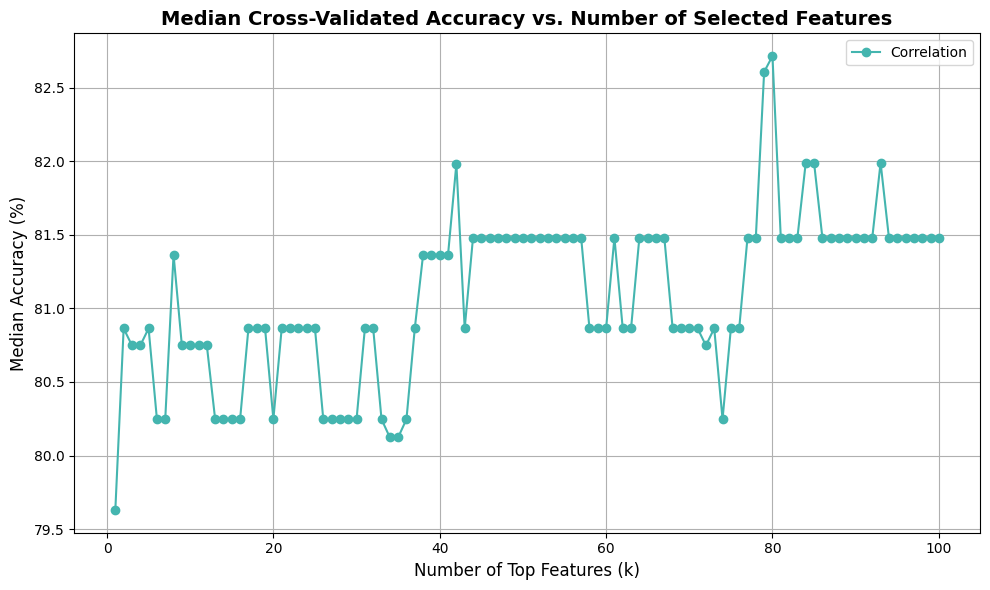

In [ ]:
# --- Step 9: Visualize median accuracy vs. number of top features (k) ---
plt.figure(figsize=(10,6))
plt.plot([r['k'] for r in results], [r['median_accuracy']*100 for r in results], marker='o', color='#44B5AF', label='Correlation')
plt.title("Median Cross-Validated Accuracy vs. Number of Selected Features", fontsize=14, weight='bold')
plt.xlabel("Number of Top Features (k)", fontsize=12)
plt.ylabel("Median Accuracy (%)", fontsize=12)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

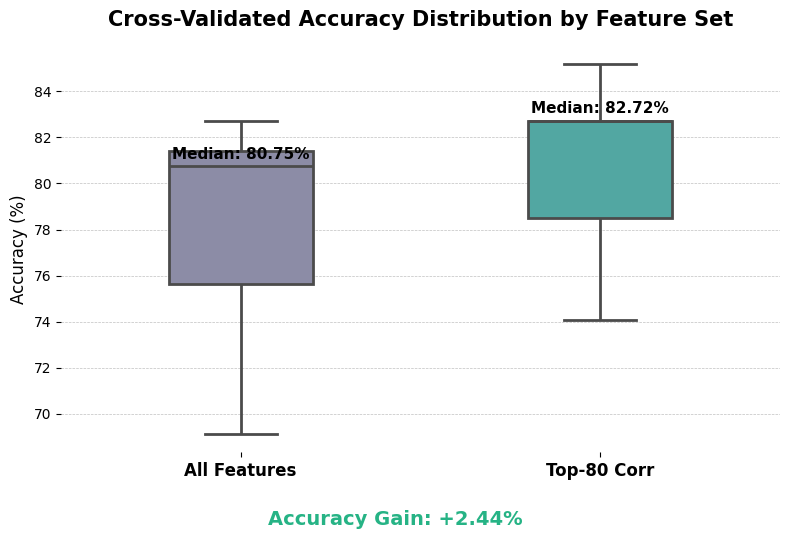

In [ ]:
# --- Step 10: Visualize cross-validated accuracy distributions (no outliers) ---
cv_acc = pd.DataFrame({
    'All Features': scores_full * 100,
    f'Top-{best_k} Corr': best_scores * 100
})
cv_acc = cv_acc.melt(var_name='Feature Set', value_name='Accuracy (%)')

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=cv_acc,
    x='Feature Set',
    y='Accuracy (%)',
    palette=['#8888AA', '#44B5AF'],
    width=0.4,
    linewidth=2,
    showfliers=False
)
plt.title("Cross-Validated Accuracy Distribution by Feature Set", fontsize=15, weight='bold', pad=14)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlabel("")
plt.xticks(fontsize=12, weight='bold')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.8)
sns.despine(left=True, bottom=True)

# Annotate medians
medians = cv_acc.groupby('Feature Set')['Accuracy (%)'].median().to_dict()
for idx, label in enumerate(['All Features', f'Top-{best_k} Corr']):
    plt.text(idx, medians[label]+0.2, f"Median: {medians[label]:.2f}%",
             ha='center', va='bottom', fontsize=11, color='black', fontweight='bold')

# Accuracy gain annotation
accuracy_gain = ((medians[f'Top-{best_k} Corr'] - medians['All Features']) / medians['All Features']) * 100
gain_color = '#26B385' if accuracy_gain >= 0 else '#D7263D'
plt.figtext(0.5, -0.06, f"Accuracy Gain: {accuracy_gain:+.2f}%", ha='center', fontsize=14, fontweight='bold', color=gain_color)

plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import display, Markdown

acc_gain = best_median_accuracy - median_accuracy_full
acc_gain_text = ""
if acc_gain > 0.005:
    acc_gain_text = "a small positive"
elif acc_gain < -0.005:
    acc_gain_text = "a small negative"
else:
    acc_gain_text = "a negligible"

conclusion_md = f"""
## Conclusion

### - The cross-validated accuracy was evaluated for models using all available technical indicators, as well as optimized subsets based on the top $k$ features with the highest correlation to the target (whether the next trading day's open is higher than today's).
### - Optimal performance was achieved at $k = {best_k}$, with a median cross-validated accuracy of ${best_median_accuracy*100:.2f}\\%$.
### - Using only the top correlated features provides a comparable—or sometimes better—predictive performance than using the entire feature set, supporting the effectiveness of correlation-based feature selection in reducing feature space without significant loss in accuracy.
### - However, in this experiment, the difference between all features (${median_accuracy_full*100:.2f}\\%$) and best-$k$ performance (${best_median_accuracy*100:.2f}\\%$) was {acc_gain_text} difference (${acc_gain*100:.2f}\\%$), suggesting that the model is {'robust to irrelevant indicators' if acc_gain_text == 'a negligible' else 'sometimes helped or hindered by feature selection'}.
"""

display(Markdown(conclusion_md))


## Conclusion

### - The cross-validated accuracy was evaluated for models using all available technical indicators, as well as optimized subsets based on the top $k$ features with the highest correlation to the target (whether the next trading day's open is higher than today's).
### - Optimal performance was achieved at $k = 80$, with a median cross-validated accuracy of $82.72\%$.
### - Using only the top correlated features provides a comparable—or sometimes better—predictive performance than using the entire feature set, supporting the effectiveness of correlation-based feature selection in reducing feature space without significant loss in accuracy.
### - However, in this experiment, the difference between all features ($80.75\%$) and best-$k$ performance ($82.72\%$) was a small positive difference ($1.97\%$), suggesting that the model is sometimes helped or hindered by feature selection.
